# Solar Flare Prediction: Forecasting Design Improvements

This notebook is Phase 3 of the project. The focus here is to make the prediction setup more scientifically realistic before moving into a full machine-learning stage.


## Goals of This Phase

- add time-aware physical features
- inspect how flare labels change over time
- create an additional label for stronger flares (`M` and `X` class)
- replace a random split mindset with a time-based forecasting split

This keeps the project grounded in forecasting logic rather than jumping directly into more complicated ML.


In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.forecasting import (
    build_forecasting_dataset,
    plot_feature_drift,
    plot_label_rate_over_time,
    summarize_time_split,
    time_based_split,
)
from src.preprocessing import prepare_modeling_dataset

pd.set_option('display.max_columns', 80)


## Load the Labeled Dataset


In [2]:
flare_files = sorted((PROJECT_ROOT / 'data' / 'noaa_flare_reports').glob('*.txt'))
sharp_file = PROJECT_ROOT / 'data' / 'sharp_parameters.csv'

flare_df, active_df, labeled_df = prepare_modeling_dataset(flare_files, sharp_file)
forecasting_df = build_forecasting_dataset(labeled_df, flare_df)

print('Forecasting rows:', len(forecasting_df))
print('flare_next_24h positives:', int(forecasting_df['flare_next_24h'].sum()))
print('strong_flare_next_24h positives:', int(forecasting_df['strong_flare_next_24h'].sum()))


Forecasting rows: 208
flare_next_24h positives: 31
strong_flare_next_24h positives: 16


## Temporal Features

For each active region, this phase adds:
- change from the previous snapshot (`delta`)
- short rolling mean
- short rolling standard deviation

These features help capture whether an active region is becoming more magnetically stressed over time.


In [3]:
temporal_columns = [column for column in forecasting_df.columns if column.endswith('_delta') or column.endswith('_rolling_mean') or column.endswith('_rolling_std')]
forecasting_df[['observation_time', 'noaa_active_region', 'flare_next_24h', 'strong_flare_next_24h'] + temporal_columns[:9]].head()


,observation_time,noaa_active_region,flare_next_24h,strong_flare_next_24h,USFLUX_delta,USFLUX_rolling_mean,USFLUX_rolling_std,AREA_ACR_delta,AREA_ACR_rolling_mean,AREA_ACR_rolling_std,TOTUSJH_delta,TOTUSJH_rolling_mean,TOTUSJH_rolling_std
0,2026-02-01 00:00:00+00:00,4349,0,0,0.000000e+00,4.032213e+22,0.000000e+00,0.000000,1304.599243,0.000000,0.000,1752.747000,0.000000
1,2026-02-01 12:00:00+00:00,4349,0,0,-6.984560e+21,3.682985e+22,4.938830e+21,-375.992676,1116.602905,265.866971,-318.210,1593.642000,225.008449
2,2026-02-02 00:00:00+00:00,4349,0,0,-5.480350e+21,3.383897e+22,6.247563e+21,-302.132751,953.226542,339.732440,-431.265,1396.852000,376.155969
3,2026-02-02 12:00:00+00:00,4349,0,0,-9.380060e+21,2.655732e+22,7.515002e+21,-276.458588,635.031870,289.390592,-290.287,1050.264667,363.064120
4,2026-02-03 00:00:00+00:00,4349,0,0,-9.138649e+21,1.855763e+22,9.259617e+21,-157.930206,389.524689,219.873041,-389.301,679.980333,340.994052


## Time-Based Split

A forecasting system should learn from earlier data and be evaluated on later data. This is more realistic than mixing all timestamps randomly.


In [4]:
train_df, test_df, split_time = time_based_split(forecasting_df, train_fraction=0.7)
split_summary = summarize_time_split(train_df, test_df, split_time)
split_summary


,subset,rows,positive_rate,strong_flare_rate,time_boundary_utc
0,train,145,0.096552,0.075862,2026-02-05 12:00:00+00:00
1,test,63,0.269841,0.079365,2026-02-05 12:00:00+00:00


## Forecasting Diagnostics

These plots show whether the event rate and the mean physical features evolve over the sampled time interval.


In [5]:
label_rate_path = plot_label_rate_over_time(forecasting_df, PROJECT_ROOT / 'figures')
feature_drift_path = plot_feature_drift(forecasting_df, PROJECT_ROOT / 'figures')

print('Label-rate figure:', label_rate_path)
print('Feature-drift figure:', feature_drift_path)


Label-rate figure: C:\Users\stude\OneDrive\Desktop\Projects\Solar Flare Prediction\solar_flare_prediction\figures\daily_flare_label_rate.png
Feature-drift figure: C:\Users\stude\OneDrive\Desktop\Projects\Solar Flare Prediction\solar_flare_prediction\figures\feature_drift_over_time.png


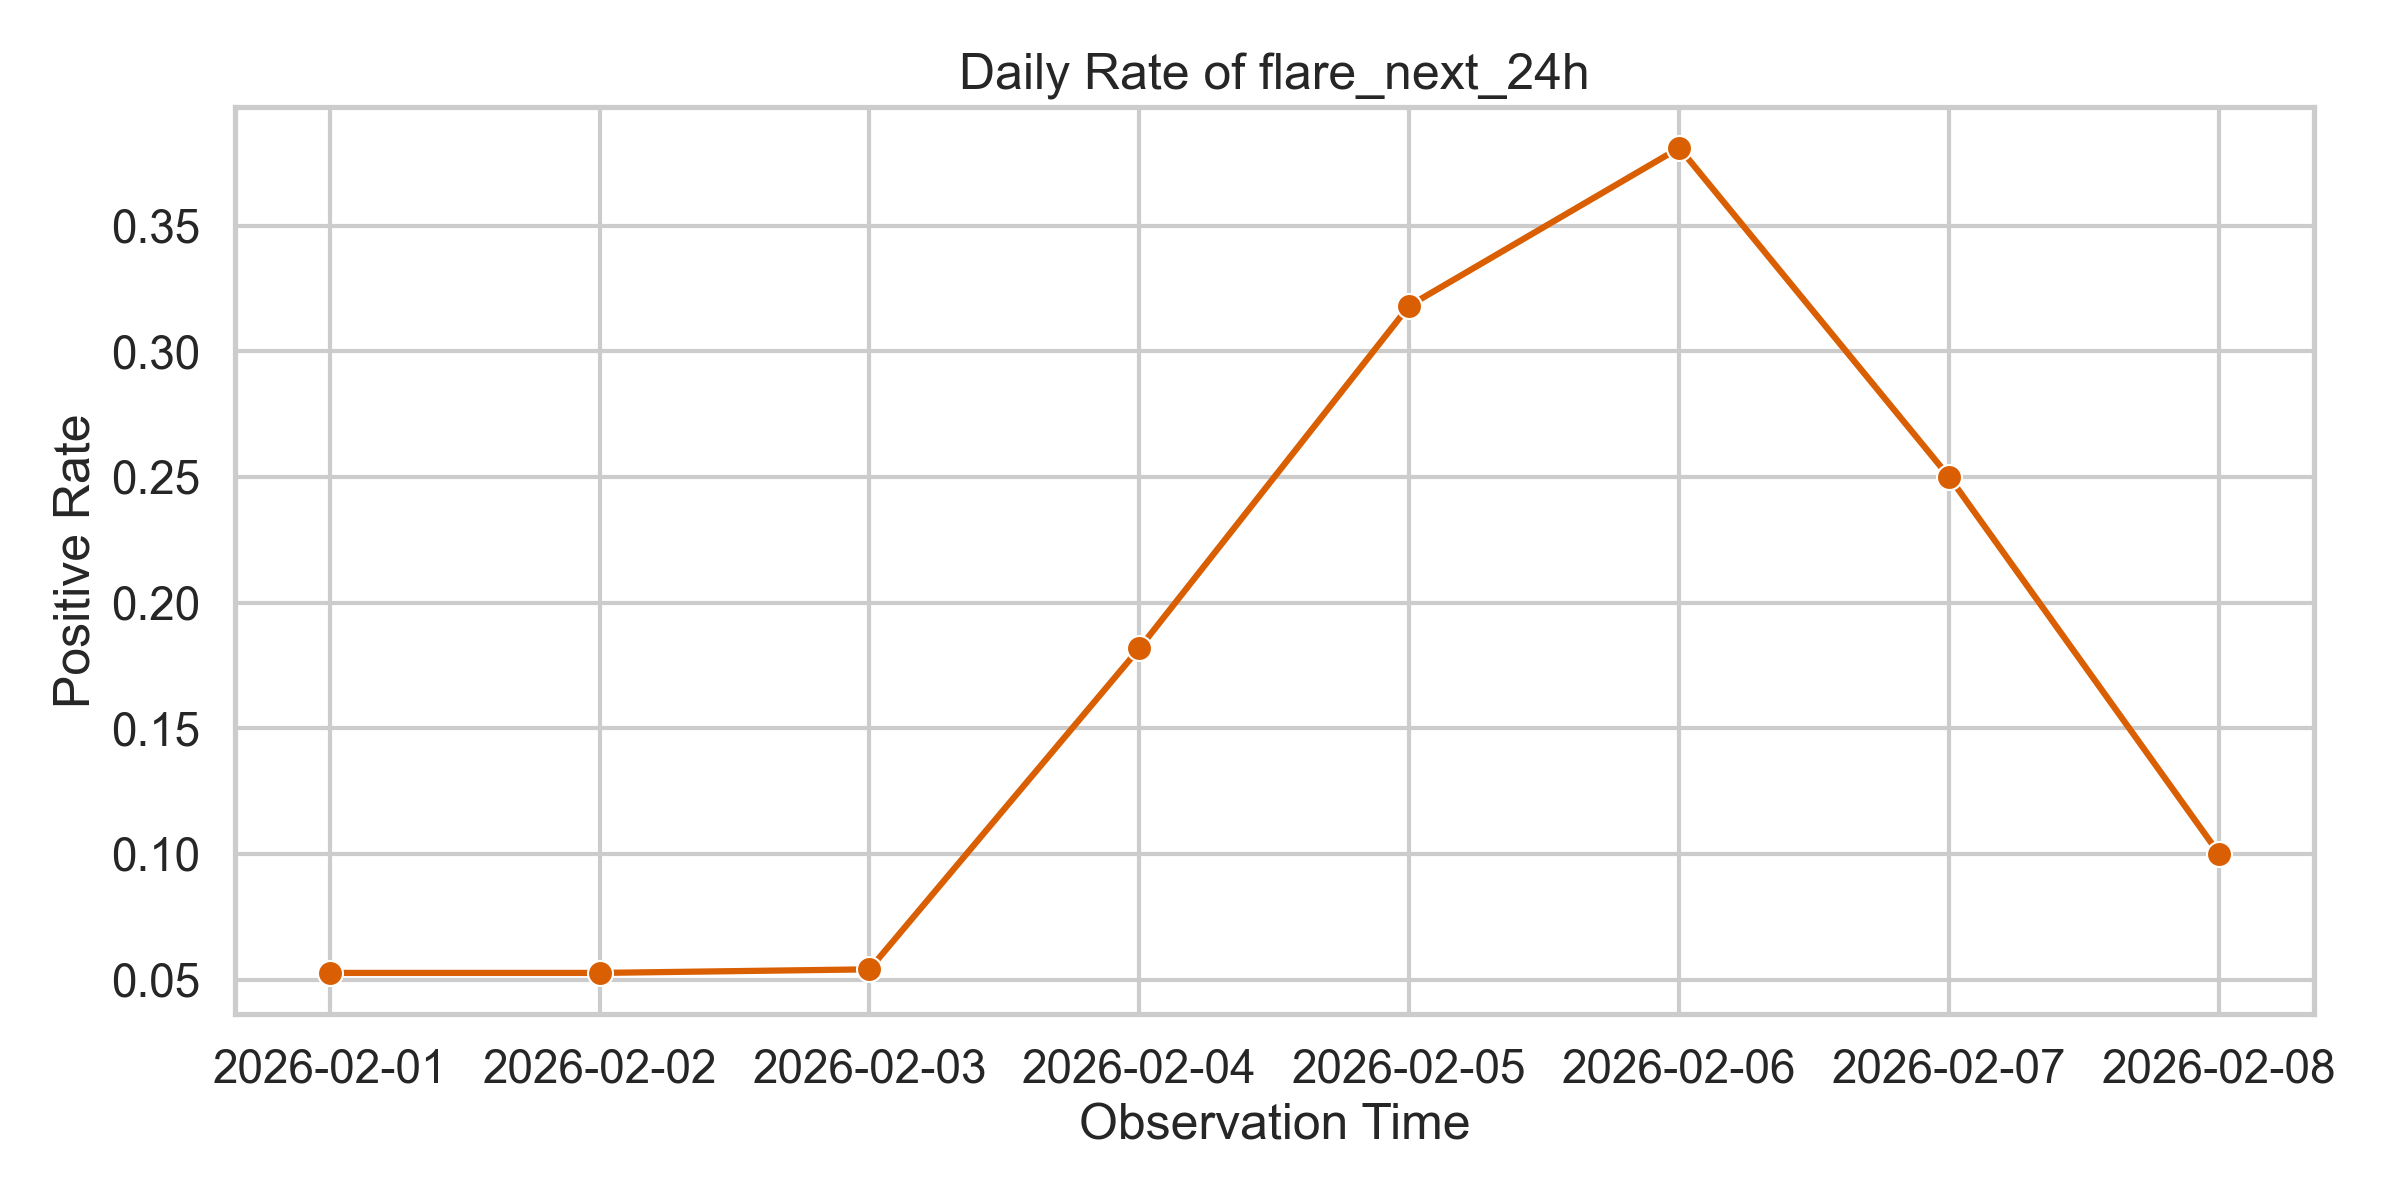

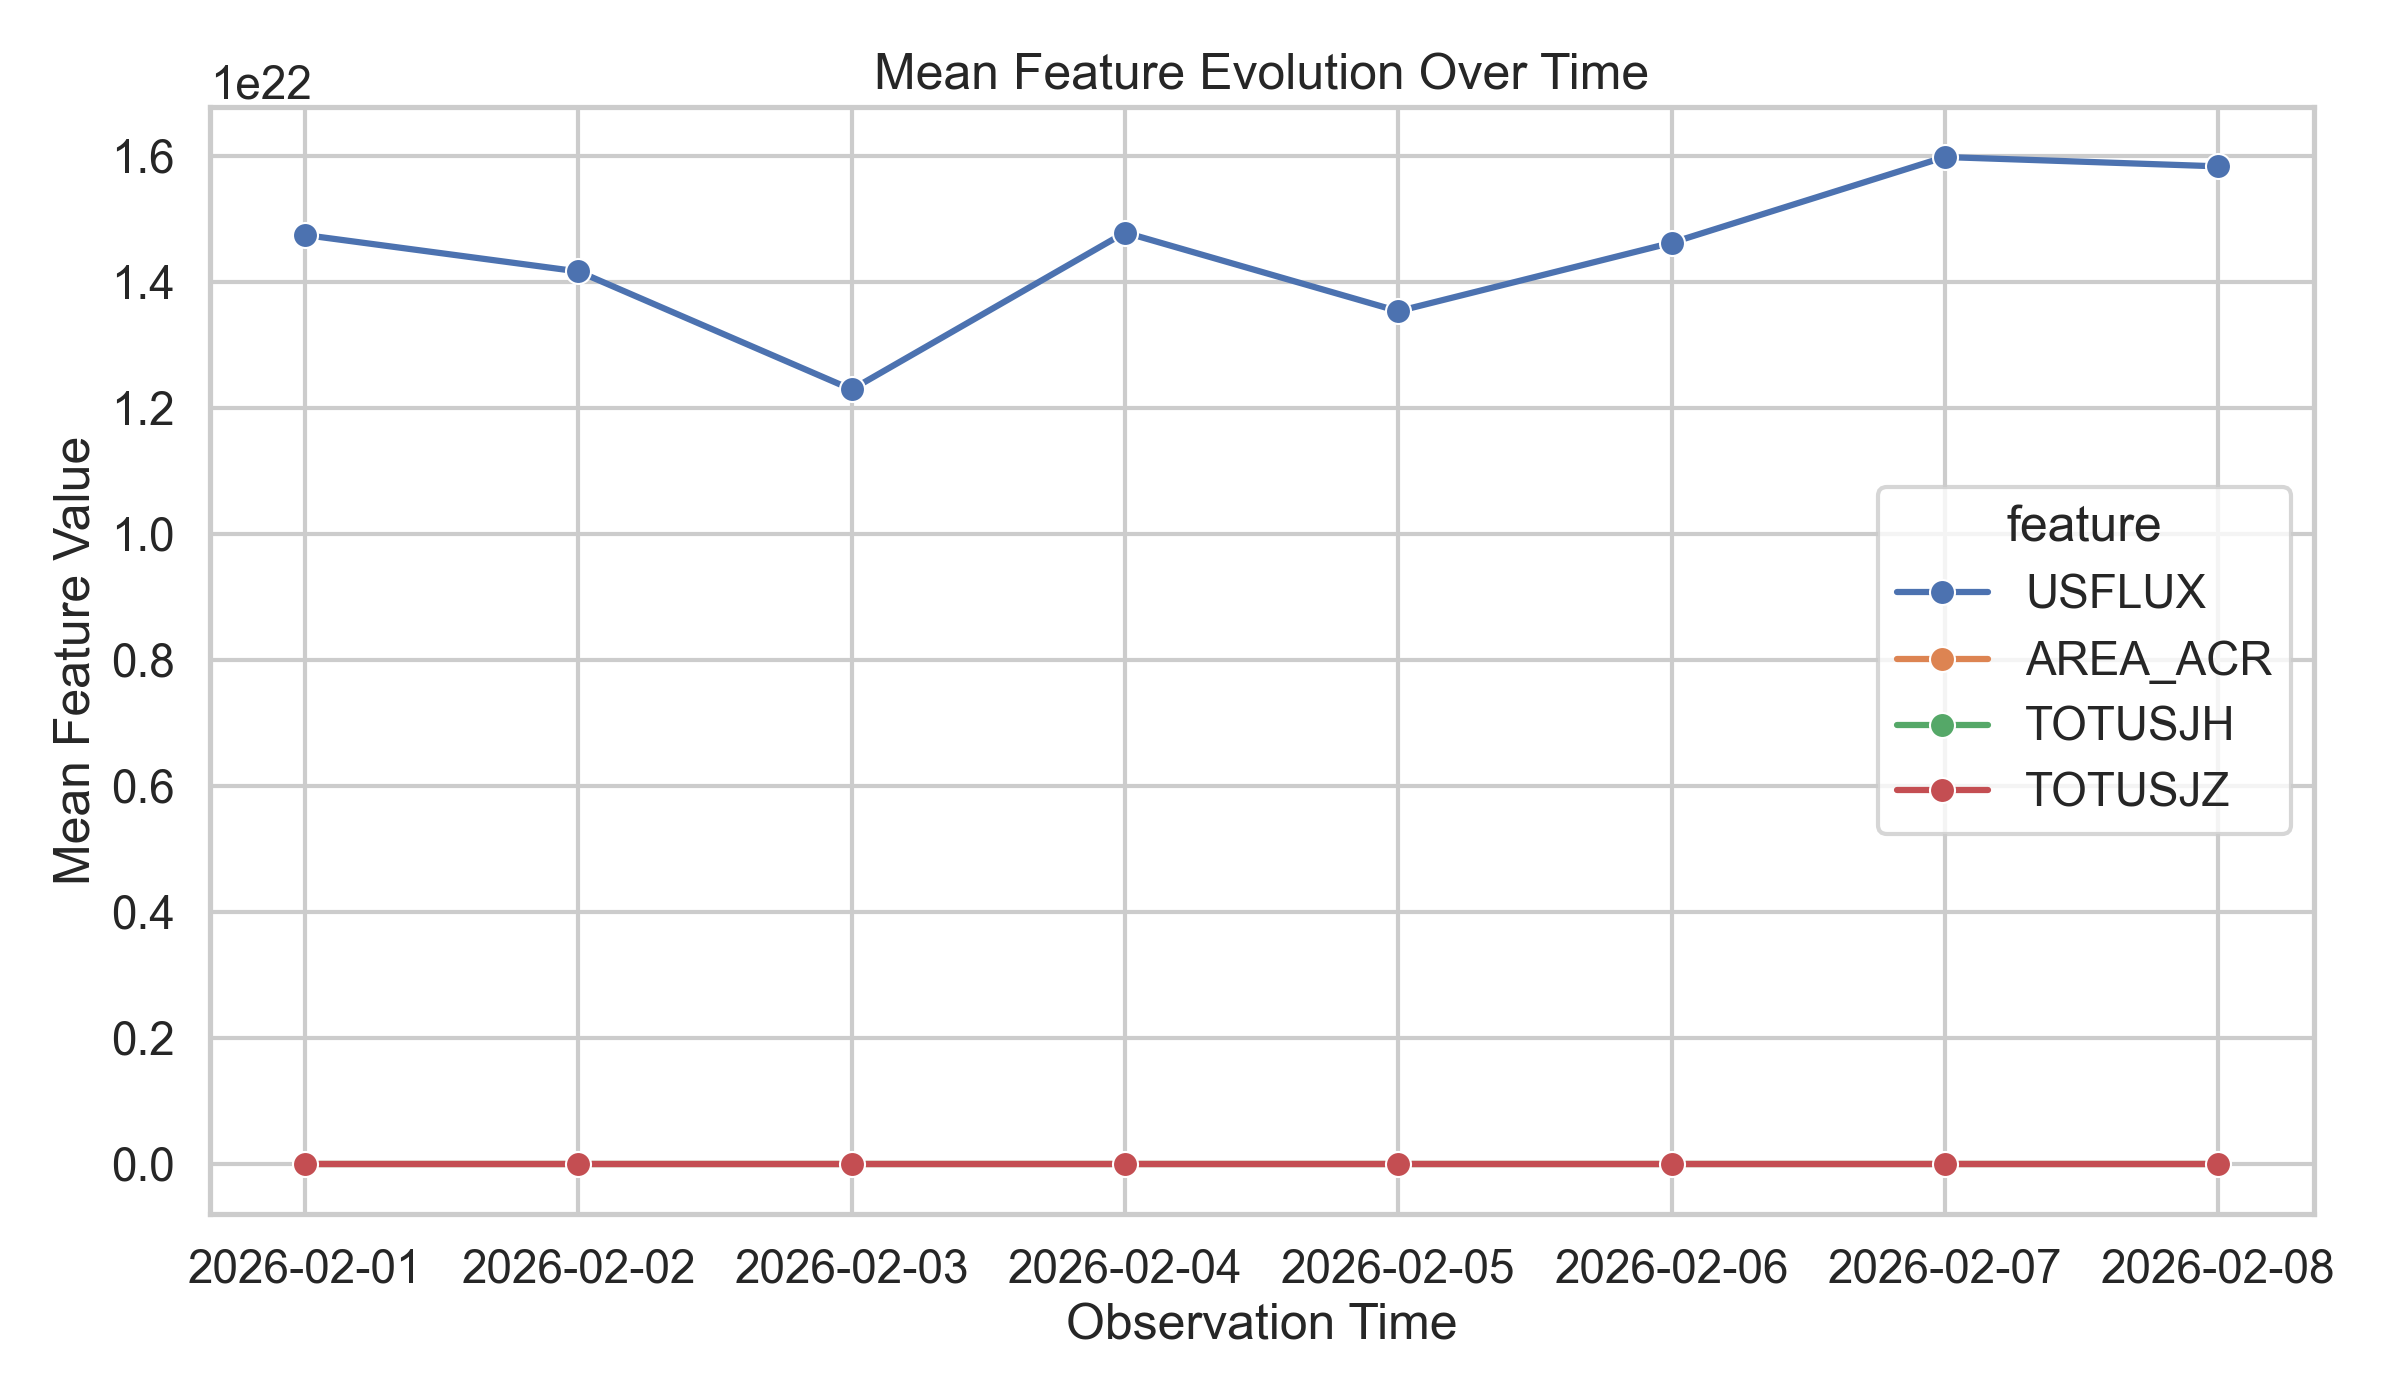

In [6]:
from IPython.display import Image, display

display(Image(filename=str(label_rate_path)))
display(Image(filename=str(feature_drift_path)))


## Interpretation

This phase improves the scientific setup in three ways:

- It uses evolving magnetic behavior, not only single-time snapshots.
- It distinguishes all flares from stronger flares.
- It introduces a chronological train/test boundary for realistic forecasting.

The next phase can build on this by extending the historical time range and only then moving into a more serious machine-learning workflow.
